# Gráficos de histogramas

Un gráfico de histograma nos permite dibujar la forma como están distribuidos nuestros datos. Esencialmente contiene una serie de barras donde la altura de cada una de estas corresponde a la cantidad (o a la frecuencia relativa) de datos en un rango específico.

Por ejemplo, supongamos un set de datos muy simple:

- Rango de valores de 1 a 10: 3 datos
- Rango de valores de 11 a 20: 2 datos
- Rango de valores de 21 a 30: 4 datos

Este histograma tendría la siguiente forma:

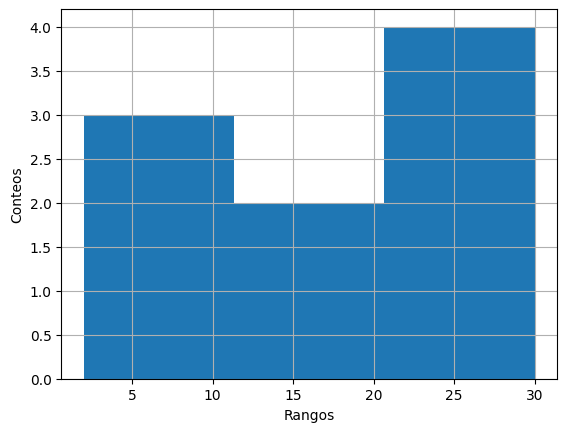

In [1]:
# Importar librerías
import matplotlib.pyplot as plt
import pandas as pd

# Crear el set de datos sintético
x = [3, 2, 4, 12, 17, 22, 21, 30, 22]

# Generar un histograma simple
fig, ax = plt.subplots()
ax.hist(x, bins=3)
ax.set_xlabel('Rangos')
ax.set_ylabel('Conteos')
ax.grid()

¡Y esta es la idea básica del histograma! En el ejemplo anterior hemos visto cómo graficar un histograma para mostrar el conteo de datos en cada rango, en un momento veremos cómo mostrarlo como una distribución de probabilidades (frecuencia relativa).

En general podemos usar un histograma en Ciencia de Datos y Machine Learning cuando:

- Queremos entender la distribución de nuestros datos (muy útil en el Análisis Exploratorio de Datos)
- Queremos determinar si hay *outliers* en nuestros datos
- Queremos comparar la distribución de diferentes categorías de datos (por ejemplo si estamos diseñando un clasificador)

Veamos otras opciones de visualización, tomando como base el archivo *histograma_dataset.csv*, que contiene datos de la altura de casi 20.000 personas entre hombres y mujeres:

In [2]:
# Leer el set de datos
df = pd.read_csv('histograma_dataset.csv')
df

,Sexo,Altura (cm)
0,Femenino,160
1,Femenino,161
2,Masculino,166
3,Femenino,164
4,Masculino,163
...,...,...
19468,Masculino,165
19469,Femenino,157
19470,Femenino,166
19471,Masculino,165


En total tenemos 19473 datos.

Creemos dos subsets correspondientes a las alturas de hombres y mujeres respectivamente:

In [3]:
# Extraer subset Sexo = Femenino
df_fem = df.loc[df['Sexo']=='Femenino']
df_fem

,Sexo,Altura (cm)
0,Femenino,160
1,Femenino,161
3,Femenino,164
5,Femenino,164
6,Femenino,159
...,...,...
19463,Femenino,164
19464,Femenino,168
19466,Femenino,155
19469,Femenino,157


In [4]:
# Extraer subset Sexo = Masculino
df_msc = df.loc[df['Sexo']=='Masculino']
df_msc

,Sexo,Altura (cm)
2,Masculino,166
4,Masculino,163
8,Masculino,160
9,Masculino,168
10,Masculino,159
...,...,...
19465,Masculino,165
19467,Masculino,162
19468,Masculino,165
19471,Masculino,165


Tenemos 10123 datos correspondientes al sexo Femenino y 9350 correspondientes al sexo masculino.

Generemos un primer par de histogramas para cada subset usando Matplotlib:

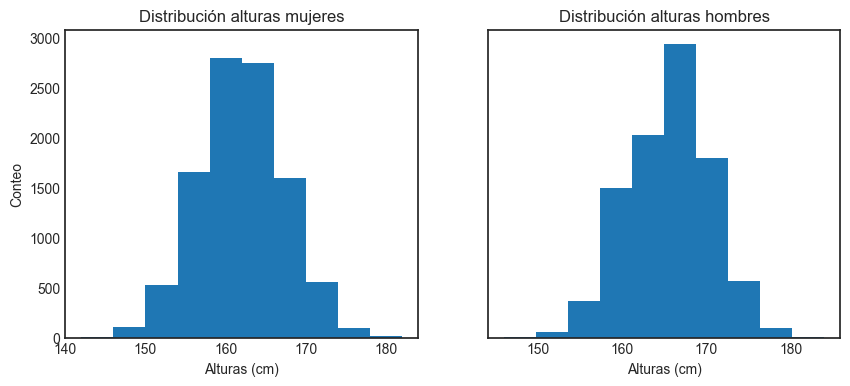

In [5]:
# Seleccionar estilo
plt.style.use('seaborn-v0_8-white')

# Generar histogramas básicos (conteo de ocurrencias)
fig, axs = plt.subplots(1, 2, figsize=(10,4), sharey=True)
axs[0].hist(df_fem['Altura (cm)'])
axs[1].hist(df_msc['Altura (cm)'])

# Agregar títulos y etiquetas a los ejes
axs[0].set_title('Distribución alturas mujeres')
axs[1].set_title('Distribución alturas hombres')
axs[0].set_xlabel('Alturas (cm)')
axs[1].set_xlabel('Alturas (cm)')
axs[0].set_ylabel('Conteo');

Donde en la gráfica anterior hemos usado algunas herramientas vistas en lecciones anteriores (como el agregar múltiples *Axes* a una misma figura, ajustar el tamaño del objeto *Figure* y compartir los ejes.

Ahora podemos comenzar a personalizar las gráficas. Una opción es modificar el parámetro `bins`, que define el número de subniveles entre los que se dividirá la variable altura.

En las gráficas generadas anteriormente este parámetro tiene un valor por defecto igual a 10. Generemos un nuevo par de histogramas pero fijando este parámetro en 25:

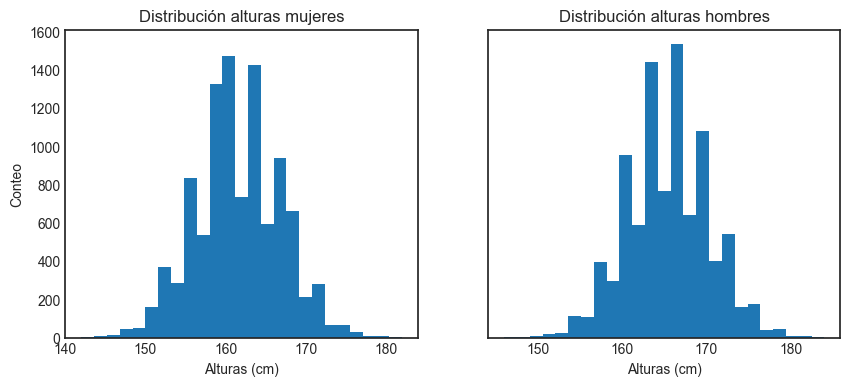

In [6]:
# Parámetros adicionales
nbins = 25

# Generar histogramas básicos (conteo de ocurrencias)
fig, axs = plt.subplots(1, 2, figsize=(10,4), sharey=True)
axs[0].hist(df_fem['Altura (cm)'], bins = nbins)
axs[1].hist(df_msc['Altura (cm)'], bins = nbins)

# Agregar títulos y etiquetas a los ejes
axs[0].set_title('Distribución alturas mujeres')
axs[1].set_title('Distribución alturas hombres')
axs[0].set_xlabel('Alturas (cm)')
axs[1].set_xlabel('Alturas (cm)')
axs[0].set_ylabel('Conteo');

Ahora agreguemos una grilla para poder extraer más detalles de las gráficas:

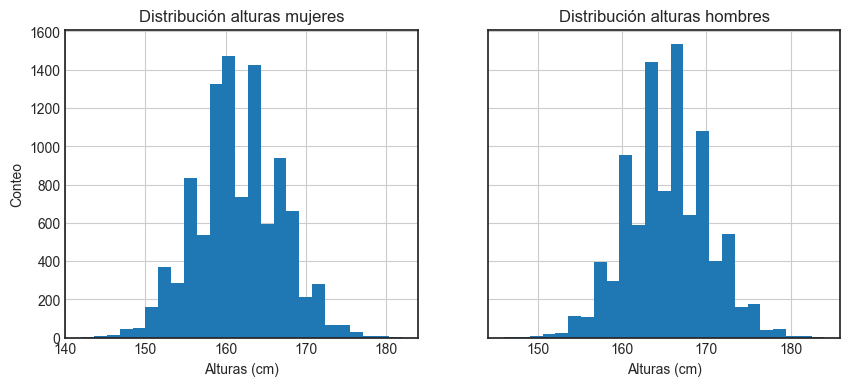

In [8]:
# Parámetros adicionales
nbins = 25

# Generar histogramas básicos (conteo de ocurrencias)
fig, axs = plt.subplots(1, 2, figsize=(10,4), sharey=True)
axs[0].hist(df_fem['Altura (cm)'], bins = nbins)
axs[1].hist(df_msc['Altura (cm)'], bins = nbins)

# Agregar títulos y etiquetas a los ejes
axs[0].set_title('Distribución alturas mujeres')
axs[1].set_title('Distribución alturas hombres')
axs[0].set_xlabel('Alturas (cm)')
axs[1].set_xlabel('Alturas (cm)')
axs[0].set_ylabel('Conteo')

# Agregar grillas (list comprehension)
[ax.grid(True) for ax in axs];

Y modifiquemos el nivel de transparencia de cada histograma a 0.5:

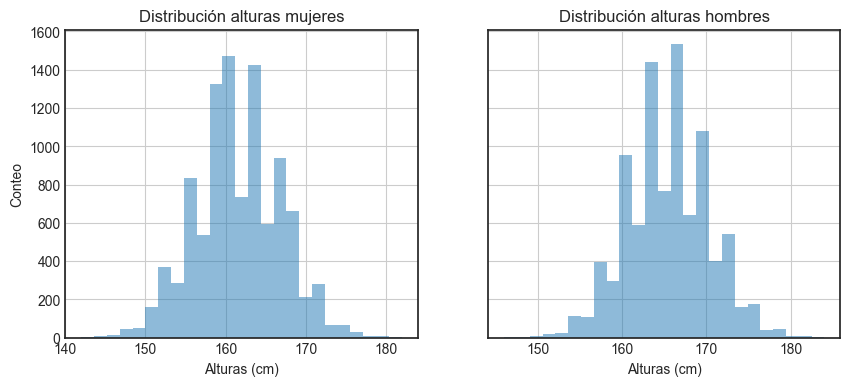

In [9]:
# Parámetros adicionales
nbins = 25
alfa = 0.5

# Generar histogramas básicos (conteo de ocurrencias)
fig, axs = plt.subplots(1, 2, figsize=(10,4), sharey=True)
axs[0].hist(df_fem['Altura (cm)'], bins = nbins, alpha = alfa)
axs[1].hist(df_msc['Altura (cm)'], bins = nbins, alpha = alfa)

# Agregar títulos y etiquetas a los ejes
axs[0].set_title('Distribución alturas mujeres')
axs[1].set_title('Distribución alturas hombres')
axs[0].set_xlabel('Alturas (cm)')
axs[1].set_xlabel('Alturas (cm)')
axs[0].set_ylabel('Conteo')

# Agregar grillas (list comprehension)
[ax.grid(True) for ax in axs];

Y con esto ya podemos interpretar las gráficas. Por ejemplo, observamos que:

- Para las mujeres el rango de alturas está entre 145 y 180 cm aproximadamente, mientras que para hombres dicho rango va de 150 a casi 185 cm aproximadamente. Es decir: los hombres son ligeramente más altos que las mujeres
- El valor medio para el caso de las mujeres es cercano a 162 cm, mientras que para hombres es de 165
- Para ambos casos sólo una mínima cantidad de la población (menos de 50 personas) tiene alturas inferiores a 150 cm y superiores a 175 cm para el caso de las mujeres o inferiores a 152 cm y superiores a 178 cm para el caso de los hombres.

Esto es lo que permite precisamente el histograma: analizar la distribución de nuestros datos.

En lugar de dibujar los histogramas como un conteo podemos dibujarlas como una distribución de probabilidades. Es decir que el eje vertical ahora estará normalizado en el rango de 0 a 1 y la altura de cada barra indicará una densidad de probabilidad (probabilidad/ancho de cada bin):

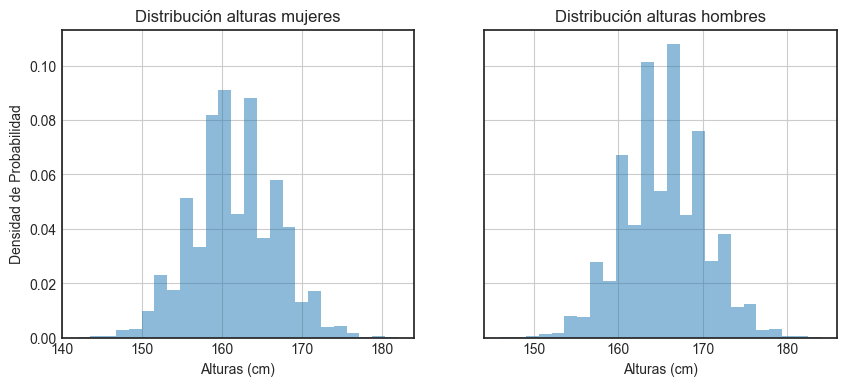

In [11]:
# Parámetros adicionales
nbins = 25
alfa = 0.5
densidad = True

# Generar histogramas básicos (conteo de ocurrencias)
fig, axs = plt.subplots(1, 2, figsize=(10,4), sharey=True)
axs[0].hist(df_fem['Altura (cm)'], bins = nbins, alpha = alfa, density = densidad)
axs[1].hist(df_msc['Altura (cm)'], bins = nbins, alpha = alfa, density = densidad)

# Agregar títulos y etiquetas a los ejes
axs[0].set_title('Distribución alturas mujeres')
axs[1].set_title('Distribución alturas hombres')
axs[0].set_xlabel('Alturas (cm)')
axs[1].set_xlabel('Alturas (cm)')
axs[0].set_ylabel('Densidad de Probabilidad')

# Agregar grillas
[ax.grid(True) for ax in axs];

Así que si multiplicamos la altura de cada barra por su ancho y sumamos los valores individuales tendremos un valor exactamente igual a 1.0: ¡el área bajo la curva!

También podemos dibujar ambos histogramas en un mismo par de *Axes*, cada uno de los cuales con un color que dependerá de la secuencia definida en el estilo que hemos seleccionado:

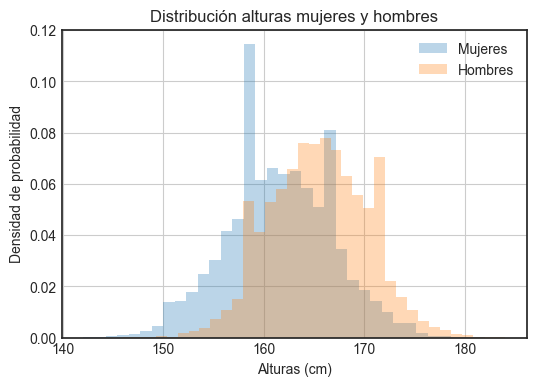

In [12]:
# Parámetros adicionales en formato diccionario
kwargs = dict(alpha=0.3, density=True, bins=35)

# Generar dos histogramas en un mismo "Axes"
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(df_fem['Altura (cm)'], **kwargs, label = 'Mujeres')
ax.hist(df_msc['Altura (cm)'], **kwargs, label = 'Hombres')

# Agregar título y etiquetas a los ejes
ax.set_title('Distribución alturas mujeres y hombres')
ax.set_xlabel('Alturas (cm)')
ax.set_ylabel('Densidad de probabilidad')

# Agregar grilla
ax.grid(True)

# Agregar leyenda
ax.legend();

Y con esta gráfica tenemos una comparación directa entre ambas distribuciones y podemos, por ejemplo, verificar que en efecto los hombres tienen alturas ligeramente mayores que las mujeres.